In [7]:
import numpy as np
import utilities as utils
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

### Script parameters and variables

In [5]:
savedir = "./Figures/"
saveflag = False

def savefig(fig, name, ftype="svg", saveflag=saveflag, savedir=savedir):
    if saveflag:
        fig.savefig(savedir + name + "." + ftype, bbox_inches="tight", dpi=300)

beads_datadir = "./Data/beads/"
horses_datadir = "./Data/horses/"

# generative parameters for the horse prediction experiments
paramdict = {
    'lowWS': {
        'weakLLR': 0.45,
        'WSratio': 1.3,
        'p1': 0.06
    },
    'midWS': {
        'weakLLR': 0.2,
        'WSratio': 2.5,
        'p1': 0.08
    },
    'highWS': {
        'weakLLR': 0.18,
        'WSratio': 6.3,
        'p1': 0.02
    }
}

### Import preprocessed data

In [ ]:
# bead prediction trial sequence
beads_trial_seq = pd.read_csv(beads_datadir + "trial_sequence.csv")
jars_emp = beads_trial_seq['jar'].to_numpy()
beads_emp = beads_trial_seq['bead'].to_numpy()

# horse prediction experiment trial sets (emp = empirical data)
lowWS_trial_set = pd.read_csv(horses_datadir + "lowWS/trial_set.csv")
Xlow_emp = utils.split_to_four_digits(lowWS_trial_set['observation_encoding'].to_numpy())
Ylow_emp = lowWS_trial_set['latent_state'].to_numpy() - 1

midWS_trial_set = pd.read_csv(horses_datadir + "midWS_learning/trial_set.csv")
Xmid_emp = utils.split_to_four_digits(midWS_trial_set['observation_encoding'].to_numpy())
Ymid_emp = midWS_trial_set['latent_state'].to_numpy() - 1

highWS_trial_set = pd.read_csv(horses_datadir + "highWS/trial_set.csv")
Xhigh_emp = utils.split_to_four_digits(highWS_trial_set['observation_encoding'].to_numpy())
Yhigh_emp = highWS_trial_set['latent_state'].to_numpy() - 1

### Figure 1

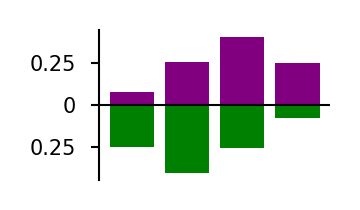

In [9]:
weakLLR = paramdict['midWS']['weakLLR']
WSratio = paramdict['midWS']['WSratio']
pdist1, pdist2 = utils.llr2probs_4shapes(llr=np.array([-weakLLR*WSratio, -weakLLR, weakLLR, weakLLR*WSratio]), p1=paramdict['midWS']['p1'])

fig, ax = plt.subplots(figsize=(1.3,0.8), dpi=300)

ax.bar(np.arange(4), pdist1, color='purple', label='state 1')

ax.bar(np.arange(4), -pdist2, color='green', label='state 2')
xlims = ax.get_xlim()
ax.plot(xlims, [0,0], color='black', linewidth=0.5)
ax.set_xlim(xlims)
ax.axes.get_xaxis().set_visible(False)
ax.set_yticks([-0.25, 0, 0.25])
ax.set_yticklabels(['0.25','0','0.25'])

# set font size of y ticks
ax.tick_params(axis='y', labelsize=5)
ax.tick_params(axis='x', labelsize=5, width=0.5, length=2)
ax.tick_params(axis='y', labelsize=5, width=0.5, length=2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# ax.spines['left'].set_position(('outward', 5))
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)

plt.tight_layout()
savefig(fig, 'Figure1/figure1_likelihoods')
# plt.savefig(savedir+'Figure1/figure1_likelihoods.svg', bbox_inches='tight')

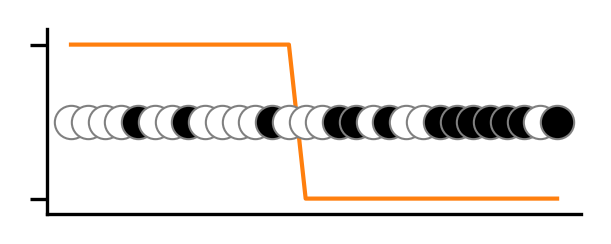

In [ ]:
mfcs = {
    0: 'black',
    1: 'white'
}

mecs = {
    1: 'gray',
    0: 'gray'
}

cmap = plt.get_cmap("tab10")

fig = plt.figure(figsize=(2.3,0.8), dpi=300)
ax = fig.add_subplot(111)

ax.plot(jars_emp[55:85],c=cmap(1),linewidth=1)
for tt in range(55,85):
    ax.plot(tt-55,0.5,'o',markersize=8,markeredgewidth=0.5,mec=mecs[beads_emp[tt]],mfc=mfcs[beads_emp[tt]])
ax.set_ylim([-0.1,1.1])
ax.set_xticks([])
ax.set_yticks([0,1],labels=[])

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.8)

ax.tick_params(axis='x', labelsize=5, width=0.8, length=4)
ax.tick_params(axis='y', labelsize=5, width=0.8, length=4)
sns.despine()
# ax.spines['bottom'].set_linewidth(0.5)
# ax.spines['left'].set_linewidth(0.5)
savefig(fig, 'Figure1/figure1_bead_seq')

### Figure 2

In [ ]:
import matplotlib.colors as mcolors

start_color = "#ffffff"  
end_color = "#136666"    

def get_color(index,values,vmin,vmax):
    return np.clip(1-(values[index]-vmin)/(vmax-vmin),0,1)

cmap_t = mcolors.LinearSegmentedColormap.from_list("custom_cmap", [start_color, end_color])